In [1]:
%reload_ext autoreload
%autoreload 2

from src.backtest import Backtest
from src.pattern import Pattern, Bollinger, High, GoldenCross, Trending, Disparity

# 기본설정

In [2]:
start = "2000-01-01"
end = "2025-12-31"
end_book = '2011-12-31'

bm = Pattern(name='모든주식')
bt = Backtest(start, end, benchmark=bm)

모든주식 | codes:   0%|          | 0/3499 [00:00<?, ?it/s]

# 모든 주식

### 무차별 선택

In [3]:
stats = bt.analyze()
stats.to_frame()

count  arith_mean  geom_mean  rise_prob
pattern period scope                                                
모든주식    1W     overall  11490693.0    0.002614  -0.001247   0.462506
        2W     overall  11459341.0    0.005276  -0.002242   0.463692
        3W     overall  11432267.0    0.007980  -0.003186   0.463306
        1M     overall  11410343.0    0.010665  -0.004152   0.461397
        2M     overall  11332168.0    0.020445  -0.008009   0.459408
        3M     overall  11257941.0    0.029266  -0.011834   0.456440
        6M     overall  11042527.0    0.058772  -0.020638   0.451731

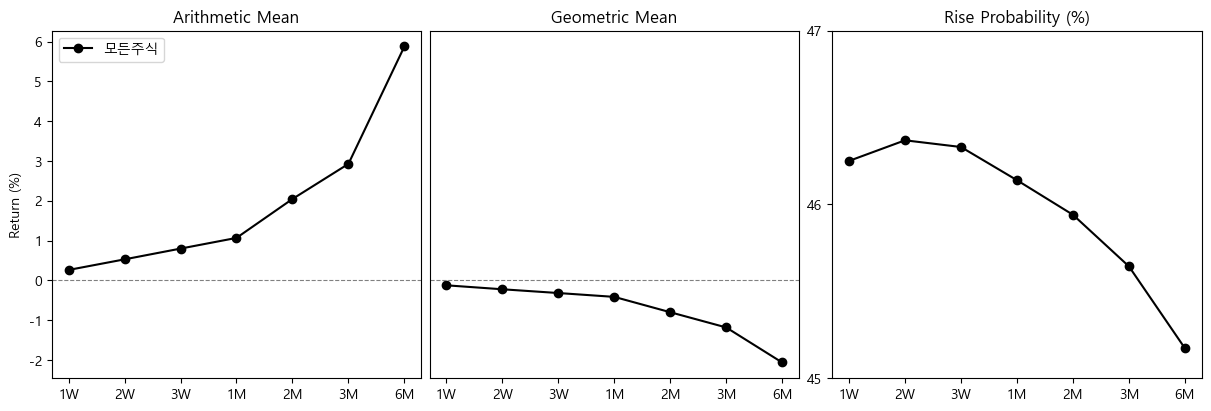

In [4]:
stats.plot(end=end);

돌파 폭8% | codes:   0%|          | 0/3499 [00:00<?, ?it/s]

돌파 폭8% + 52주 고가 | codes:   0%|          | 0/3499 [00:00<?, ?it/s]

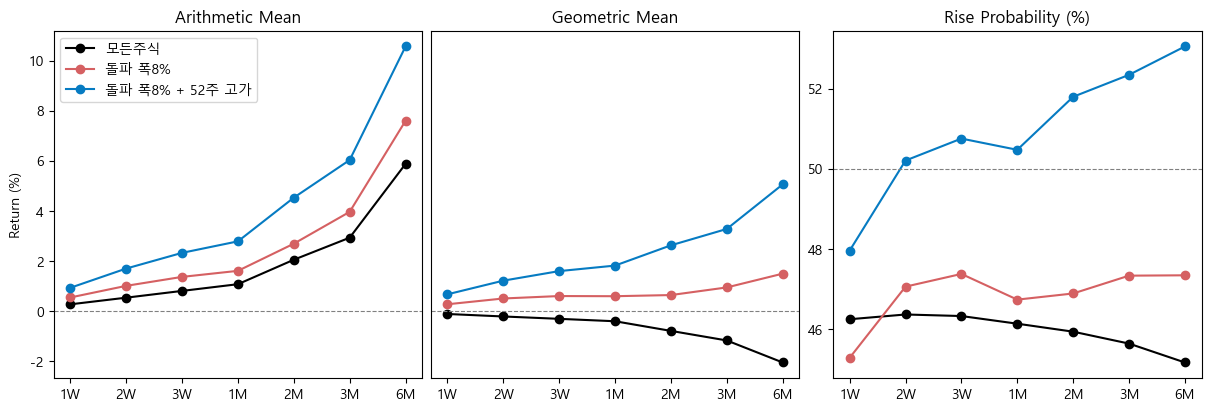

In [19]:
bb8 = Bollinger(name='돌파 폭8%').on(trigger='breakout_up', breakout_cooldown_days=3, bandwidth_max=0.08)
high52w = High(name='52주 고가').on(window=252, threshold=0.90, stay_days=1)
bb_high52w = bb8 + high52w

stats = bt.analyze(bb8, bb_high52w)
stats.plot(end=end)

In [20]:
bt.screen('2025-12-30', bb_high52w)

돌파 폭8% + 52주 고가 | mask:   0%|          | 0/3499 [00:00<?, ?it/s]

,name,close
code,,
031330,에스에이엠티,4150.0
033920,무학,9450.0
037460,삼지전자,14740.0
352820,하이브,330000.0
